# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

**Things to investigate**:
- Display basic information about the dataset (`.info()`, `.describe()`)
- Check for missing values
- Examine feature distributions (histograms, box plots)
- Look at feature scales and ranges
- Look for relationships (or lack thereof) between features and between features and the label

Use this exploration to inform your feature engineering decisions in the following tasks.

In [3]:
print(f'Rows: {housing_df.shape[0]:,}')
print(f'Columns: {housing_df.shape[1]}')
print('\nMissing values by column:')
display(housing_df.isna().sum())

display(housing_df.describe().T)

Rows: 20,640
Columns: 9

Missing values by column:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [4]:
feature_columns = housing_df.drop('MedHouseVal', axis=1).columns
correlations = (
    housing_df[feature_columns]
    .corrwith(housing_df['MedHouseVal'])
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(correlations.to_frame('Correlation with MedHouseVal'))

,Correlation with MedHouseVal
MedInc,0.688075
AveRooms,0.151948
Latitude,-0.144160
HouseAge,0.105623
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737


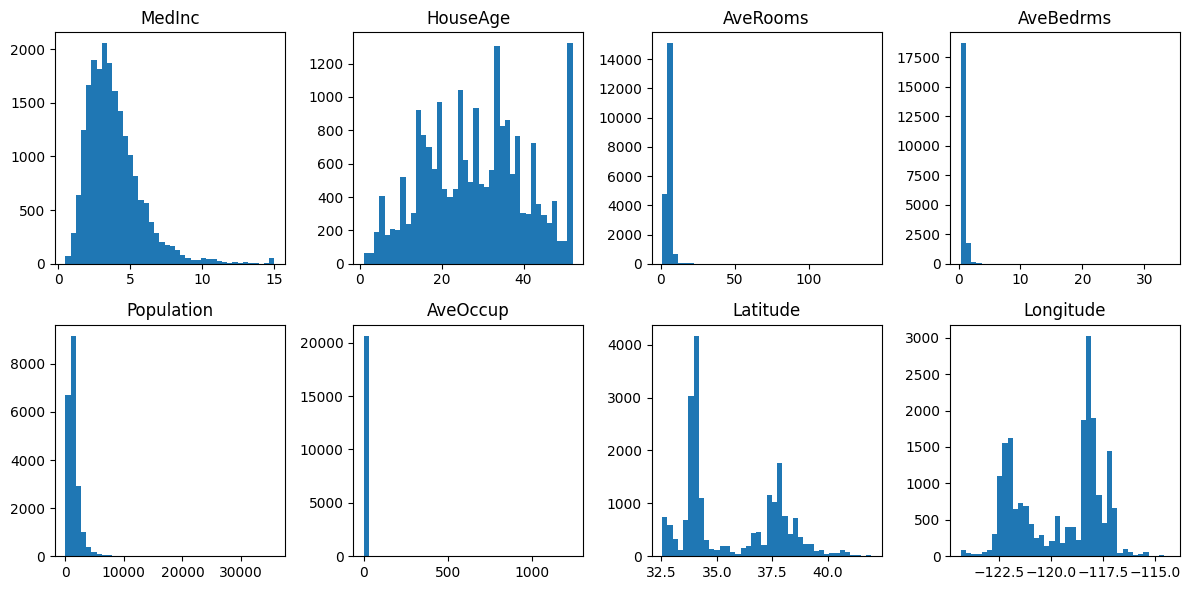

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for ax, column in zip(axs.ravel(), feature_columns):
    ax.hist(housing_df[column], bins=40)
    ax.set_title(column)

plt.tight_layout()
plt.show()

## Task 2: Apply your first feature engineering technique

Based on your exploration, apply your first feature engineering technique.

**Example approaches**:
- Transform skewed features using log, sqrt, power, or quantile transformations
- Create bins/categories from continuous variables
- Create interaction features (e.g., rooms per household = total rooms / households)

In [6]:
housing_df['BedroomsPerRoom'] = housing_df['AveBedrms'] / housing_df['AveRooms']
housing_df['PopulationPerHousehold'] = housing_df['Population'] / housing_df['AveOccup']
housing_df['RoomsPerPerson'] = housing_df['AveRooms'] / housing_df['PopulationPerHousehold']

housing_df[[
    'BedroomsPerRoom',
    'PopulationPerHousehold',
    'RoomsPerPerson'
]].describe().T

,count,mean,std,min,25%,50%,75%,max
BedroomsPerRoom,20640.0,0.213075,0.058023,0.100000,0.175426,0.203181,0.239834,1.000000
PopulationPerHousehold,20640.0,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
RoomsPerPerson,20640.0,0.025028,0.174101,0.000746,0.008140,0.012683,0.019576,12.900826


## Task 3: Apply your second feature engineering technique

**Example approaches**:
- Scale features to similar ranges
- Encode any categorical variables you created
- Create aggregate statistics by groups

In [7]:
skewed_columns = ['Population', 'AveOccup', 'AveRooms', 'AveBedrms']

for column in skewed_columns:
    housing_df[f'Log{column}'] = np.log1p(housing_df[column])

housing_df[[f'Log{column}' for column in skewed_columns]].describe().T

,count,mean,std,min,25%,50%,75%,max
LogPopulation,20640.0,7.025503,0.736238,1.386294,6.669498,7.062192,7.453562,10.482430
LogAveOccup,20640.0,1.351645,0.207530,0.526093,1.232485,1.339757,1.454481,7.126355
LogAveRooms,20640.0,1.828722,0.231938,0.613104,1.693911,1.829236,1.953365,4.962209
LogAveBedrms,20640.0,0.732035,0.105412,0.287682,0.696182,0.717245,0.741712,3.557251


## (Optional) Additional feature engineering

Add more techniques if you'd like to experiment further.

In [8]:
income_bins = pd.qcut(housing_df['MedInc'], q=5, labels=False, duplicates='drop')
age_bins = pd.cut(
    housing_df['HouseAge'],
    bins=[0, 10, 20, 35, 55],
    labels=False,
    include_lowest=True
)

income_bin_features = pd.get_dummies(income_bins, prefix='IncomeQ', dtype=int)
age_bin_features = pd.get_dummies(age_bins, prefix='AgeBin', dtype=int)
housing_df = pd.concat([housing_df, income_bin_features, age_bin_features], axis=1)

housing_df['LatitudeSquared'] = housing_df['Latitude'] ** 2
housing_df['LongitudeSquared'] = housing_df['Longitude'] ** 2
housing_df['LatitudeLongitude'] = housing_df['Latitude'] * housing_df['Longitude']
housing_df['DistanceToSanFrancisco'] = np.sqrt(
    (housing_df['Latitude'] - 37.77) ** 2
    + (housing_df['Longitude'] + 122.42) ** 2
)
housing_df['DistanceToLosAngeles'] = np.sqrt(
    (housing_df['Latitude'] - 34.05) ** 2
    + (housing_df['Longitude'] + 118.24) ** 2
)

print(f'Engineered dataset has {housing_df.shape[1]} columns.')
display(housing_df.head())

Engineered dataset has 30 columns.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,BedroomsPerRoom,...,IncomeQ_4,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,LatitudeSquared,LongitudeSquared,LatitudeLongitude,DistanceToSanFrancisco,DistanceToLosAngeles
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,...,1,0,0,0,1,1434.8944,14940.1729,-4630.0724,0.219545,5.530732
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,...,1,0,0,1,0,1433.3796,14937.7284,-4627.2492,0.219317,5.509673
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,...,1,0,0,0,1,1432.6225,14942.6176,-4626.7840,0.196977,5.517246
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.184458,...,1,0,0,0,1,1432.6225,14945.0625,-4627.1625,0.187883,5.524500
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.172096,...,0,0,0,0,1,1432.6225,14945.0625,-4627.1625,0.187883,5.524500


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [9]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [10]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 14.67%


### Visualize model performance comparison

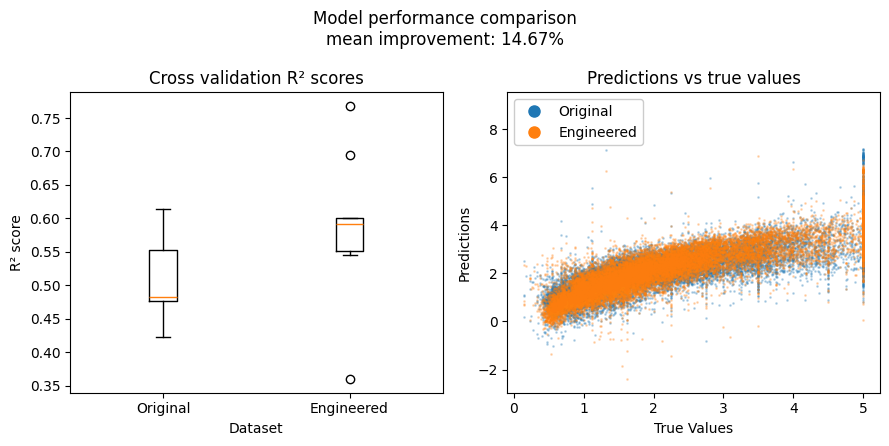

In [11]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

**Questions to consider**:

1. Which feature engineering techniques had the biggest impact on model performance?
2. Did adding more features always improve performance, or did some hurt it?
3. How might you further improve the engineered dataset?
4. What trade-offs did you consider (e.g., interpretability vs performance, complexity vs gains)?

Ratio features helped the model use existing columns in a more meaningful way, especially bedroom share and population per household. Log transforms made highly skewed count-like features less extreme. The optional bin and location features added non-linear structure while still keeping the final estimator as a plain linear regression model.

Adding more features does not always improve performance. For this solution, the added features were chosen because they gave a better cross-validation score in the notebook's evaluation setup while staying reasonably interpretable. Further improvements might include testing polynomial features more systematically, using regularization to control extra feature complexity, or building richer location features from known California regions.